In [ ]:
#웹페이지를 지정해서 페이지를 구성하는 html요소를 가져오는 역할
!pip install requests

#가져온 웹 페이지에서 정보를 추출
!pip install beautifulsoup4

In [ ]:
import requests
from bs4 import BeautifulSoup as bs
import re

In [ ]:
#1. requests로 웹페이지 가져오기
response = requests.get("https://n.news.naver.com/mnews/article/016/0002419234")
print(response)

<Response [200]>


In [ ]:
html_text = response.text

#파서를 배정
soup = bs(html_text, 'html.parser')
print(soup)

<!DOCTYPE html>

<html data-useragent="python-requests/2.32.3" lang="ko">
<head>
<meta charset="utf-8"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta content="width=device-width, initial-scale=1.0, maximum-scale=1.0, minimum-scale=1.0, user-scalable=no" name="viewport">
<meta content="KAIST, 유전자 발현 조절 ‘단백질’ 원리 규명" property="og:title"/>
<meta content="article" property="og:type"/>
<meta content="https://n.news.naver.com/mnews/article/016/0002419234" property="og:url"/>
<meta content="https://imgnews.pstatic.net/image/016/2025/01/22/0002419234_001_20250122083816312.jpg?type=w800" property="og:image"/>
<meta content="- 생명과학과 김세윤·이광록·조원기 교수 공동 연구팀 - 세포 증식, 사멸 및 암 질환 치료 이해 넓힐 것 기대 이번 연구를 수행한 KAIST 생명과학과 연구진. 김세윤(윗줄 왼쪽부터), 이광록 교수, 안형준, 유정" property="og:description"/>
<meta content="헤럴드경제 | 네이버" property="og:article:author"/>
<meta content="summary_large_image" name="twitter:card"/>
<meta content="KAIST, 유전자 발현 조절 ‘단백질’ 원리 규명" name="twitter:title"/>
<meta content="네이버 뉴스" name

In [ ]:
news_content = soup.select('div.newsct_article')
print(news_content)

[<div class="newsct_article _article_body" id="newsct_article">
<article class="go_trans _article_content" id="dic_area">
<div style="display:box;border-left:solid 4px rgb(228, 228, 228);padding-left: 20px; padding-right: 20px;">- 생명과학과 김세윤·이광록·조원기 교수 공동 연구팀 <br/>- 세포 증식, 사멸 및 암 질환 치료 이해 넓힐 것 기대</div><br/><br/><table class="nbd_table"><tr><td><span class="end_photo_org"><div class="nbd_im_w _LAZY_LOADING_WRAP">
<div class="nbd_a _LAZY_LOADING_ERROR_HIDE" id="img_a1">
<img alt="" class="_LAZY_LOADING _LAZY_LOADING_INIT_HIDE" data-src="https://imgnews.pstatic.net/image/016/2025/01/22/0002419234_001_20250122083816312.jpg?type=w860" id="img1" style="display: none;">
</img></div>
</div></span></td></tr><tr><td>이번 연구를 수행한 KAIST 생명과학과 연구진. 김세윤(윗줄 왼쪽부터), 이광록 교수, 안형준, 유정민 박사, 조원기 교수, 류광민 박사과정.[KAIST 제공]</td></tr></table><br/><br/>[헤럴드경제=구본혁 기자] KAIST는 생명과학과 김세윤, 이광록, 조원기 교수 공동연구팀이 동물 세포의 유전자 발현을 조절하는 핵심적인 원리를 규명했다고 22일 밝혔다.<br/><br/>이노시톨 대사 효소에 의해 만들어지는 이노시톨 인산 대사체는 진핵 세포의 신호전달 시스템에 필요한 다양한 이차 

In [ ]:
#'<.+?>' -> html 태그
content = re.sub('<.+?>', '' , str(news_content), 0).strip()

#[\[\]] -> 대괄호[]
#대괄호를 지우는 역할
pattern = r'[\[\]]'
content = re.sub(pattern, '', content).strip()

In [ ]:
print(content)

- 생명과학과 김세윤·이광록·조원기 교수 공동 연구팀 - 세포 증식, 사멸 및 암 질환 치료 이해 넓힐 것 기대



이번 연구를 수행한 KAIST 생명과학과 연구진. 김세윤(윗줄 왼쪽부터), 이광록 교수, 안형준, 유정민 박사, 조원기 교수, 류광민 박사과정.KAIST 제공헤럴드경제=구본혁 기자 KAIST는 생명과학과 김세윤, 이광록, 조원기 교수 공동연구팀이 동물 세포의 유전자 발현을 조절하는 핵심적인 원리를 규명했다고 22일 밝혔다.이노시톨 대사 효소에 의해 만들어지는 이노시톨 인산 대사체는 진핵 세포의 신호전달 시스템에 필요한 다양한 이차 신호전달물질로 작용하며 암, 비만, 당뇨, 신경계 질환들에 폭넓게 관여한다.연구팀은 이노시톨 대사 시스템의 핵심 효소인 IPMK 단백질이 동물 세포의 핵심 유전자 발현 네트워크의 중요한 전사 활성화 인자로 작용함을 규명했다.포도당과 유사한 영양소로 알려진 이노시톨의 대사 반응에 핵심적으로 작용하는 효소인 IPMK 단백질은 유전자 발현을 직접적으로 조절하는 기능을 가지고 있다. 특히 IPMK 효소는 동물 세포의 대표적인 전사 인자인 혈청 반응 인자(이하 SRF)에 의한 유전자 전사 과정에 중요하다고 보고된 바 있으나 작용하는 기전에 대하여 알려진 바는 없었다.SRF 전사 인자는 최소 200~300여 개의 유전자 발현을 직접적으로 조절하는 단백질로서, 동물 세포의 성장과 증식, 세포 사멸, 세포의 이동성 등을 조절하며 심장과 같은 장기 발생에 필수적이다.연구팀은 IPMK 단백질이 SRF 전사 인자와 직접적으로 결합한다는 사실을 발견하고 이를 통해 SRF 전사 인자의 3차원적 단백질 구조를 변화시킨다는 것을 밝혔다.연구팀은 IPMK 효소에 의하여 활성화된 SRF 전사 인자를 통해 다양한 유전자들의 전사 과정이 촉진된다는 것을 밝혔다. 즉, IPMK 단백질은 SRF 전사 인자의 단백질 활성을 높이는 데 반드시 필요한 조절 스위치와 같은 역할을 수행하는 것임을 연구팀은 규명했다.



이번 연구결과 모식도.KAIST 제공IPM

In [ ]:
def crawling_and_preprocessing(text):
  #1. requests로 웹페이지 가져오기
  #파서를 배정
  soup = bs(text, 'html.parser')

  news_content = soup.select('div.newsct_article')

  #'<.+?>' -> html 태그
  content = re.sub('<.+?>', '' , str(news_content), 0).strip()

  #[\[\]] -> 대괄호[]
  #대괄호를 지우는 역할
  pattern = r'[\[\]]'
  content = re.sub(pattern, '', content).strip()
  return content

In [ ]:
url = input("네이버 뉴스 링크를 입력하세요 : \n")
response = requests.get(url)
content = crawling_and_preprocessing(response.text)

네이버 뉴스 링크를 입력하세요 : 
https://n.news.naver.com/mnews/article/016/0002419234


In [ ]:
content

'- 생명과학과 김세윤·이광록·조원기 교수 공동 연구팀 - 세포 증식, 사멸 및 암 질환 치료 이해 넓힐 것 기대\n\n\n\n이번 연구를 수행한 KAIST 생명과학과 연구진. 김세윤(윗줄 왼쪽부터), 이광록 교수, 안형준, 유정민 박사, 조원기 교수, 류광민 박사과정.KAIST 제공헤럴드경제=구본혁 기자 KAIST는 생명과학과 김세윤, 이광록, 조원기 교수 공동연구팀이 동물 세포의 유전자 발현을 조절하는 핵심적인 원리를 규명했다고 22일 밝혔다.이노시톨 대사 효소에 의해 만들어지는 이노시톨 인산 대사체는 진핵 세포의 신호전달 시스템에 필요한 다양한 이차 신호전달물질로 작용하며 암, 비만, 당뇨, 신경계 질환들에 폭넓게 관여한다.연구팀은 이노시톨 대사 시스템의 핵심 효소인 IPMK 단백질이 동물 세포의 핵심 유전자 발현 네트워크의 중요한 전사 활성화 인자로 작용함을 규명했다.포도당과 유사한 영양소로 알려진 이노시톨의 대사 반응에 핵심적으로 작용하는 효소인 IPMK 단백질은 유전자 발현을 직접적으로 조절하는 기능을 가지고 있다. 특히 IPMK 효소는 동물 세포의 대표적인 전사 인자인 혈청 반응 인자(이하 SRF)에 의한 유전자 전사 과정에 중요하다고 보고된 바 있으나 작용하는 기전에 대하여 알려진 바는 없었다.SRF 전사 인자는 최소 200~300여 개의 유전자 발현을 직접적으로 조절하는 단백질로서, 동물 세포의 성장과 증식, 세포 사멸, 세포의 이동성 등을 조절하며 심장과 같은 장기 발생에 필수적이다.연구팀은 IPMK 단백질이 SRF 전사 인자와 직접적으로 결합한다는 사실을 발견하고 이를 통해 SRF 전사 인자의 3차원적 단백질 구조를 변화시킨다는 것을 밝혔다.연구팀은 IPMK 효소에 의하여 활성화된 SRF 전사 인자를 통해 다양한 유전자들의 전사 과정이 촉진된다는 것을 밝혔다. 즉, IPMK 단백질은 SRF 전사 인자의 단백질 활성을 높이는 데 반드시 필요한 조절 스위치와 같은 역할을 수행하는 것임을 연구팀은 규명했다.\n\n\n\n이번 연구결과 모식도.KA

In [ ]:
!pip install soynlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.8/416.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
from soynlp.normalizer import emoticon_normalize

In [ ]:
print(emoticon_normalize("앜ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ 진짜 웃기넼ㅋㅋㅋㅋㅋㅋ 야야 ㅋㅋㅋㅋ 나중에 또 봐줰ㅋㅋㅋ", num_repeats=2))

아ㅋㅋ 진짜 웃기네ㅋㅋ 야야 ㅋㅋ 나중에 또 봐줘ㅋㅋ


In [ ]:
content = emoticon_normalize(content, num_repeats=2)
print(content)

- 생명과학과 김세윤·이광록·조원기 교수 공동 연구팀 - 세포 증식, 사멸 및 암 질환 치료 이해 넓힐 것 기대 이번 연구를 수행한 KAIST 생명과학과 연구진. 김세윤(윗줄 왼쪽부터), 이광록 교수, 안형준, 유정민 박사, 조원기 교수, 류광민 박사과정.KAIST 제공헤럴드경제=구본혁 기자 KAIST는 생명과학과 김세윤, 이광록, 조원기 교수 공동연구팀이 동물 세포의 유전자 발현을 조절하는 핵심적인 원리를 규명했다고 22일 밝혔다.이노시톨 대사 효소에 의해 만들어지는 이노시톨 인산 대사체는 진핵 세포의 신호전달 시스템에 필요한 다양한 이차 신호전달물질로 작용하며 암, 비만, 당뇨, 신경계 질환들에 폭넓게 관여한다.연구팀은 이노시톨 대사 시스템의 핵심 효소인 IPMK 단백질이 동물 세포의 핵심 유전자 발현 네트워크의 중요한 전사 활성화 인자로 작용함을 규명했다.포도당과 유사한 영양소로 알려진 이노시톨의 대사 반응에 핵심적으로 작용하는 효소인 IPMK 단백질은 유전자 발현을 직접적으로 조절하는 기능을 가지고 있다. 특히 IPMK 효소는 동물 세포의 대표적인 전사 인자인 혈청 반응 인자(이하 SRF)에 의한 유전자 전사 과정에 중요하다고 보고된 바 있으나 작용하는 기전에 대하여 알려진 바는 없었다.SRF 전사 인자는 최소 200~300여 개의 유전자 발현을 직접적으로 조절하는 단백질로서, 동물 세포의 성장과 증식, 세포 사멸, 세포의 이동성 등을 조절하며 심장과 같은 장기 발생에 필수적이다.연구팀은 IPMK 단백질이 SRF 전사 인자와 직접적으로 결합한다는 사실을 발견하고 이를 통해 SRF 전사 인자의 3차원적 단백질 구조를 변화시킨다는 것을 밝혔다.연구팀은 IPMK 효소에 의하여 활성화된 SRF 전사 인자를 통해 다양한 유전자들의 전사 과정이 촉진된다는 것을 밝혔다. 즉, IPMK 단백질은 SRF 전사 인자의 단백질 활성을 높이는 데 반드시 필요한 조절 스위치와 같은 역할을 수행하는 것임을 연구팀은 규명했다. 이번 연구결과 모식도.KAIST 제공IPMK 효소와 

#자연어 처리 및 워드클라우드

In [ ]:
from soynlp.tokenizer import RegexTokenizer

token = RegexTokenizer()
data = token.tokenize(content)

/usr/local/lib/python3.11/dist-packages/soynlp/tokenizer/_tokenizer.py:19: FutureWarning: Possible nested set at position 13
  ('english & latin', re.compile(u"[a-zA-ZÀ-ÿ]+[[`']?s]*|[a-zA-ZÀ-ÿ]+", re.UNICODE))


In [ ]:
data = [d for d in data if len(d) >= 2]
print(data[:15])

['생명과학과', '김세윤', '이광록', '조원기', '교수', '공동', '연구팀', '세포', '증식', '사멸', '질환', '치료', '이해', '넓힐', '기대']


#불용어 제거 후 딕셔너리 제작하여 워드클라우드 만들

In [ ]:
len(data)

371

In [ ]:
!pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=a300935765656a2a20773f463edaae5dc6760fa597c774759184fb57d7249081
  Stored in directory: /root/.cache/pip/wheels/40/b3/0f/a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built wget


In [ ]:
!wget https://raw.githubusercontent.com/byungjooyoo/Dataset/main/korean_stopwords.txt

--2025-01-22 07:02:38--  https://raw.githubusercontent.com/byungjooyoo/Dataset/main/korean_stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7007 (6.8K) [text/plain]
Saving to: ‘korean_stopwords.txt’

korean_stopwords.tx 100%[===================>]   6.84K  --.-KB/s    in 0s      

2025-01-22 07:02:38 (63.8 MB/s) - ‘korean_stopwords.txt’ saved [7007/7007]



In [ ]:
with open('korean_stopwords.txt', 'r') as f:
  stop_words = f.read().split('\n')

In [ ]:
corpus = [x for x in data if x not in stop_words]
print(len(corpus))

360


In [ ]:
from collections import Counter

count = Counter(corpus)
top = count.most_common(10)
print(top)

[('전사', 13), ('SRF', 9), ('IPMK', 8), ('세포의', 7), ('유전자', 7), ('동물', 5), ('핵심', 5), ('비정형', 5), ('김세윤', 4), ('교수', 4)]


In [ ]:
#딕셔너리 형태로 만듦
dic = {}

#top이라는 리스트 내부의 튜플들을 하나하나 분석
# i[0] == 앞에있는 '단어'
# i[1] == 횟수
# dic[키 == 단어]  = 값 == 횟수
for i in top:
  word = i[0]
  val = i[1]

  dic[word] = val

In [ ]:
dic

{'전사': 13,
 'SRF': 9,
 'IPMK': 8,
 '세포의': 7,
 '유전자': 7,
 '동물': 5,
 '핵심': 5,
 '비정형': 5,
 '김세윤': 4,
 '교수': 4}

In [ ]:
#한국어 폰트 다운로드
!apt install fonts-nanum fonts-nanum-extra
!pip install wordcloud

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-extra
0 upgraded, 2 newly installed, 0 to remove and 49 not upgraded.
Need to get 31.4 MB of archives.
After this operation, 120 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 MB]
Fetched 31.4 MB in 2s (16.5 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 124561 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (202

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from wordcloud import WordCloud

#다운로드 받은 한글 폰트를 사용하도록 matplotlib 에 등록
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

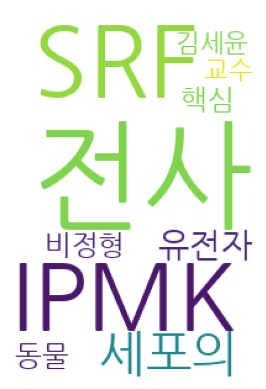

In [ ]:
wc = WordCloud(font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
               background_color ='white',
               width=200, height=300).generate_from_frequencies(dic) #딕셔너리를 참고해서 그리는 wc
               # 키(단어) : 값(단어의 등장 횟수) -> 빈도에 따라 단어 사이즈 조절

plt.axis('off')
plt.imshow(wc)
#plt.savefig('저장하려는 위치')

In [ ]:
#pip install kiwipiepy